예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)


In [1]:

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()



- 다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
- 공통 라이브러리의 `set_seed()` 함수(6장부터 사용): 지금까지 사용한 파이썬 표준 라이브러리, 파이토치, 넘파이의 난수 발생 초기화를 묶어서 실행하는 함수이다.


In [2]:
SEED = 42
common.set_seed(SEED)

42


- `device`: 실습 환경에 맞는 하드웨어 가속기 장치 객체
- 공통 라이브러리의 `get_device()`` 함수 사용


In [3]:

device = common.get_device()

CUDA를 사용합니다.


# 6-3 순서를 기준으로 판단하는 모델 만들기

본 노트북은 본문 6-3 절의 코드 예제([코드 6-11] ~ [코드 6-17])를 절 흐름 그대로 모은 것이다. 띄어쓰기가 제거된 영어 문자열에 띄어쓰기를 다시 추가하는 이진 분류 모델을 단순 RNN과 LSTM 두 가지로 만들고 비교한다.

다루는 내용
- `[코드 6-11]` 원본 문자열에서 입력과 정답 문자열 만들기
- `[코드 6-12]` 샘플 어휘 사전과 데이터셋
- `[코드 6-13]` 띄어쓰기 모델의 학습 데이터 준비
- `[코드 6-14]` 띄어쓰기를 학습하는 SpacingRNN 모델 정의와 객체 생성
- `[코드 6-15]` 장치 이동이 가능한 학습 함수와 띄어쓰기 모델의 학습
- `[코드 6-16]` 띄어쓰기의 예측
- `[코드 6-17]` LSTM 계층을 사용한 띄어쓰기 모델 클래스

> 소설 '오즈의 마법사' 텍스트는 깃허브 저장소 규약(§13.9)에 따라 `'../../data/wonderful_wizard_of_oz.txt'` 로 읽는다. 본문 산문은 `data/` 디렉터리를 안내하므로 경로 의미가 같다.

이번 절은 본문의 모델 8의 구현을 포함한다. 모델 8의 제시문은 다음과 같다.

> **모델 8. 오즈의 띄어쓰기**
>
> 1900년 L. 프랭크 바움(L. Frank Baum)은 동화 <오즈의 마법사>를 발표했다. 신문 기자 출신답게 군더더기 없는 쉬운 문체에 담아낸 감각적인 소설은 오늘날 미국을 대표하는 고전이 되었다. 소설 <오즈의 마법사>를 학습한 모델을 사용해 띄어쓰기가 없는 영어 문자열에 띄어쓰기를 추가해 보자. 입력 문자열과 출력 문자열의 예시는 다음과 같다.
>
> - 입력: `iwanttomakeacoolstuff,soistudydeeplearning.`
> - 출력: `i want to make a cool stuff, so i study deep learning.`
>
> 편의상 다음과 같은 가정을 한다.
> - 대소문자는 구분하지 않는다. 텍스트에 포함된 대문자는 모두 소문자로 바꿔 사용한다. 예측할 때 입력하는 문자열도 마찬가지다. 
> - `str.isspace()`가 `True`를 반환하는 줄바꿈, 탭 등의 공백 문자는 모두 띄어쓰기로 취급하며, 두 칸 이상 연속된 띄어쓰기는 한 칸만 띄어 쓴 것으로 간주한다.
> - 쉼표, 마침표, 따옴표와 같은 문장 부호는 하나의 글자로 취급한다. 참고로 소설 원문에 포함된 큰따옴표와 작은따옴표는 키보드로 입력할 수 있는 `'`, `"`와 다른 글자이며 여는 따옴표와 닫는 따옴표가 구분되어 있다.
>
> <오즈의 마법사> 소설 원문은 `https://www.gutenberg.org/cache/epub/55/pg55.txt`에서 내려받아도 되고 , 깃허브 저장소 `data` 디렉터리의 `wonderful_wizard_of_oz.txt` 파일을 사용해도 된다.


## [코드 6-11] 원본 문자열에서 입력과 정답 문자열 만들기

`generate_train_data()` 는 입력 텍스트를 소문자로 바꾸고 공백을 모두 제거한 입력 시퀀스를 만든다. 동시에 각 문자 다음에 띄어쓰기가 있는지(0/1)를 표시한 정답 시퀀스도 만든다. 끝에 1을 더하는 것은 '문자열 끝 다음에도 띄어쓰기가 있다'는 가정에 대응하며, `re.sub('01+', '1', ...)` 로 연속 공백을 하나로 정규화한다.

In [5]:
# 참고 - 원본 문자열에서 입력과 정답 문자열 만들기

import re

# 입력 문자열(input_text)에 대응하는 정답 문자열을 만드는 함수
def making_spacing_example(input_text):
    # 문자열 앞뒤의 공백 문자를 제거하고 대문자를 소문자로 변환
    input_text = input_text.strip().lower()
    # 공백 문자를 모두 제거한 입력 순차 데이터
    input_sequence = ''.join(char for char in input_text if not char.isspace())
    # 공백 위치를 1, 나머지를 0으로 표기한 뒤, 문자열 끝에도 1을 하나 붙임
    # ('문자열 끝 다음에도 띄어쓰기가 있다'는 가정에 대응)
    space_location = ''.join(
        '1' if char.isspace() else '0' for char in input_text
    ) + '1'
    # 연속된 공백(01, 011, ...)을 하나의 공백(1)으로 정규화
    target_sequence = re.sub('01+', '1', space_location)
    # 두 시퀀스의 길이는 항상 같음
    return input_sequence, target_sequence

original_text = 'I love you.'                       # 테스트 문자열
test_in, test_tar = making_spacing_example(original_text)
print(f'원본 문장: {original_text}')
print(f'입력: {test_in} (길이 {len(test_in)})')     # 출력값: iloveyou., 9
print(f'정답: {test_tar} (길이 {len(test_tar)})')   # 출력값: 100010001, 9

원본 문장: I love you.
입력: iloveyou. (길이 9)
정답: 100010001 (길이 9)


'I love you.'는 'iloveyou.'(공백 제거된 입력)와 '100010001'(공백 위치 표시)로 변환된다. 각 문자 위치 다음에 띄어쓰기가 있으면 1, 없으면 0이다.

## [코드 6-12] 샘플 어휘 사전과 데이터셋

`SpacingDataset` 은 6-2 절의 `MelodyDataset` 과 거의 같지만, 정답 데이터(`target_sequence`)를 별도로 받고 `<eos>` 토큰을 사용하지 않는다. `__getitem__` 은 윈도우 안 문자들을 원-핫 인코딩한 `(window_size, vocab_size)` 텐서를 입력으로, 윈도우 마지막 글자 다음의 띄어쓰기 여부(0 또는 1)를 정답으로 반환한다.

In [ ]:
########################################################################################
# 코드 6-9 - 샘플 어휘 사전과 데이터셋
########################################################################################
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

# 띄어쓰기 데이터셋 클래스
class SpacingDataset(Dataset):
    def __init__(self, input_sequence, target_sequence, vocab, window_size):
        self.vocab = vocab
        self.window_size = window_size
        self.target_sequence = target_sequence
        # 입력 문자열을 고유 번호 텐서로 미리 변환(띄어쓰기 모델에는 <eos>가 필요 없음)
        self.sequence_idx = torch.tensor(
            [vocab[token] for token in input_sequence]
        )

    def __len__(self):
        # 슬라이딩 윈도우로 만들 수 있는 샘플 수 = 시퀀스 길이 - 윈도우 크기 + 1
        return len(self.sequence_idx) - self.window_size + 1

    def __getitem__(self, idx):
        subsequence = self.sequence_idx[idx: idx + self.window_size]
        # 입력: 윈도우 내 문자들의 원-핫 텐서(실수형 텐서)        
        x = F.one_hot(subsequence, num_classes=len(self.vocab)).float()
        # 정답: 윈도우 마지막 글자 뒤의 띄어쓰기 여부(0 또는 1, long형 텐서)
        target = self.target_sequence[idx + self.window_size - 1]
        y = torch.tensor(int(target), dtype=torch.long)
        return x, y


# 테스트용 데이터의 입력 문자열과 정답 문자열
test_data = 'I love you.'
test_input, test_target = making_spacing_example(test_data)
# 테스트용 어휘 사전 생성
test_vocab = {token: i for i, token in enumerate(sorted(set(test_input)))}
# 테스트용 데이터셋 (윈도우 크기 4, 정답 샘플은 윈도우에 포함되지 않음)
test_window_size = 4 
test_dataset = SpacingDataset(test_input, test_target, test_vocab, test_window_size)

# 생성된 어휘 사전과 데이터셋의 정보 출력
print(f'테스트 어휘 사전의 크기: {len(test_vocab)}')
print(f'테스트 데이터셋의 샘플 수: {len(test_dataset)}')
print('첫 번째 샘플의 입력 텐서:')
print(test_dataset[0][0])
print('첫 번째 샘플의 정답:', test_dataset[0][1])

테스트 어휘 사전의 크기: 8
테스트 데이터셋의 샘플 수: 6
첫 번째 샘플의 입력 텐서:
tensor([[0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.]])
첫 번째 샘플의 정답: tensor(0)


첫 번째 샘플은 'iloveyou.'의 앞 네 글자 'ilov'에 해당하는 `(4, 8)` 원-핫 텐서다. 'ilov'의 마지막 글자 'v' 뒤에는 띄어쓰기가 없으므로 정답은 0이다.

## [코드 6-13] 띄어쓰기 모델의 학습 데이터 준비

소설 '오즈의 마법사' 텍스트(`text`)로 어휘 사전, 데이터셋, 데이터로더를 만든다. 입력 샘플의 길이(`SEQUENCE_LENGTH`)는 한 문장 정도를 가정해 25로 잡는다.

In [12]:
# 참고 - 소설 '오즈의 마법사' 텍스트 로딩

from pathlib import Path

text_path = Path('../../data/wonderful_wizard_of_oz.txt')
# 'utf-8-sig': UTF-8 with BOM(Byte Order Mark)
#   BOM(Byte Order Mark)가 포함된 텍스트 파일을 처리하기 위한 인코딩 방식
text = text_path.read_text(
    encoding='utf-8-sig'
)

In [13]:
###############################################################################
# 코드 6-10 - 띄어쓰기 모델의 학습 데이터 준비
###############################################################################
from torch.utils.data import DataLoader

# 소설 <오즈의 마법사> 텍스트(text)로 어휘 사전 생성
input_sequence, target_sequence = making_spacing_example(text)
vocab = {token: i for i, token in enumerate(sorted(set(input_sequence)))}
vocab_size = len(vocab)                 # 어휘 사전의 크기(input_size)

# 데이터셋과 데이터로더 생성
SEQUENCE_LENGTH = 25                    # 입력 샘플의 길이(S)
spacing_dataset = SpacingDataset(
    input_sequence, target_sequence, vocab, SEQUENCE_LENGTH,
)

BATCH_SIZE = 128                        # 배치 크기 (B)
spacing_dataloader = DataLoader(
    spacing_dataset, batch_size=BATCH_SIZE, shuffle=True,
)

# 데이터 통계
print(f'원본 텍스트(띄어쓰기 포함) 크기: {len(text)}')
print(f'입력(띄어쓰기 제거) 크기: {len(input_sequence)}')
print(f'어휘 사전 크기: {len(vocab)}')
print(f'데이터셋의 샘플 수: {len(spacing_dataset)}개')
print(f'미니배치의 개수: {len(spacing_dataloader)}개')

원본 텍스트(띄어쓰기 포함) 크기: 227109
입력(띄어쓰기 제거) 크기: 182793
어휘 사전 크기: 61
데이터셋의 샘플 수: 182769개
미니배치의 개수: 1428개


어휘 사전은 알파벳 소문자, 문장 부호, 숫자 등으로 구성된다. 입력 순차 데이터의 길이가 25이므로 데이터셋 샘플 수는 입력 길이에서 24를 뺀 값이 된다.

## [코드 6-14] 띄어쓰기를 학습하는 SpacingRNN 모델 정의와 객체 생성

`SpacingRNN` 은 6-2 절의 `MelodyRNN` 과 뼈대가 같지만, 입력의 복잡도를 고려해 `hidden_size=256`, `num_layers=2` 로 키우고 출력은 띄어쓰기 여부 2개 클래스로 줄였다.

In [14]:
###############################################################################
# 코드 6-11 - 띄어쓰기를 학습하는 SpacingRNN 모델 정의와 객체 생성
############################################################################### 
import torch.nn as nn
from torchinfo import summary

# 단순 RNN 계층(self.rnn), 완전 연결 계층(self.fc)으로 구성된 SpacingRNN 클래스
class SpacingRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.rnn = nn.RNN(                  # 단순 RNN 계층
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        # 완전 연결 계층(분류기)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):                   # 입력 데이터 x: (B, S, input_size)
        outputs, _ = self.rnn(x)            #             -> (B, S, hidden_size)
        last_hidden = outputs[:, -1, :]     #             -> (B, hidden_size)
        return self.fc(last_hidden)         #             -> (B, output_size)

# 모델의 구조를 결정하는 하이퍼파라미터
INPUT_SIZE = vocab_size                     # 단순 RNN 계층의 input_size
HIDDEN_SIZE = 256                           # 단순 RNN 계층의 hidden_size
NUM_LAYERS = 2                              # 단순 RNN 계층의 내부 계층 수
OUTPUT_SIZE = 2                             # 띄어쓰거나 않거나의 두 개의 클래스

# 모델 객체를 생성하고 모델 요약 정보 출력
model_rnn = SpacingRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
summary(model_rnn, input_size=(BATCH_SIZE, SEQUENCE_LENGTH, INPUT_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
SpacingRNN                               [128, 2]                  --
├─RNN: 1-1                               [128, 25, 256]            213,248
├─Linear: 1-2                            [128, 2]                  514
Total params: 213,762
Trainable params: 213,762
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 682.46
Input size (MB): 0.78
Forward/backward pass size (MB): 6.56
Params size (MB): 0.86
Estimated Total Size (MB): 8.19

## [코드 6-15] 장치 이동이 가능한 학습 함수와 띄어쓰기 모델의 학습

데이터 양과 모델 규모가 크므로 하드웨어 가속기를 사용한다. 본문 [코드 6-8] 의 인라인 루프를 1 에포크 단위의 `train_epoch()` 와 에포크 반복을 감싸는 `train_loop()` 로 분리하고, 텐서를 `device` 로 이동한다. 순환 신경망의 기울기 폭주를 막기 위해 `torch.nn.utils.clip_grad_norm_()` 으로 기울기 클리핑을 적용한다.

에포크    훈련 손실     시간
  1/20       0.4228     0:08
  2/20       0.3884     0:15
  4/20       0.2695     0:30
  6/20       0.2279     0:45
  8/20       0.2087     0:59
 10/20       0.1973     1:14
 12/20       0.1917     1:29
 14/20       0.1883     1:43
 16/20       0.1865     1:57
 18/20       0.1862     2:12
 20/20       0.1873     2:26


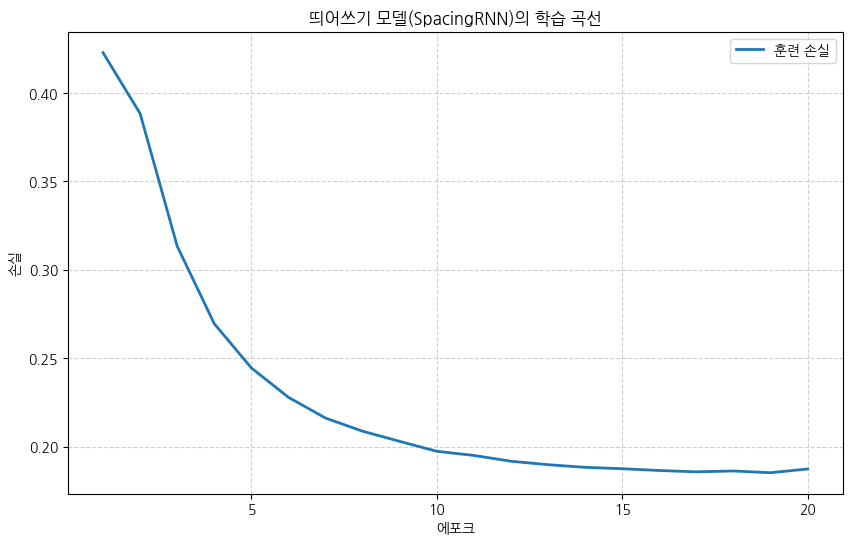

In [15]:
###############################################################################
# 코드 6-12 - 하드웨어 가속기를 사용하는 순환 신경망 모델의 1 에포크 학습 함수
###############################################################################
import torch.optim as optim

# 1 에포크 학습 함수: 기울기 클리핑을 적용하고 훈련 손실의 가중 평균값을 반환
def train_epoch(model, train_loader, criterion, optimizer, device=None):    
    if device is None:
        device = torch.device('cpu')
    model.to(device)                        # 모델을 학습 장치로 이동
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        # 배치 텐서를 하드웨어 가속기로 이동
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()               
        outputs = model(inputs)             # 순전파
        loss = criterion(outputs, labels)   # 손실 계산
        loss.backward()                     # 역전파
        # 기울기 클리핑: 기울기 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()                    # 최적화
        # 손실과 샘플 수 집계
        #    배치마다 샘플 수가 다를 수 있어 합산 후 마지막에 가중 평균 계산
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size           # 평균 훈련 손실 반환(가중 평균)

# 학습 하이퍼파라미터, 손실 함수, 옵티마이저
LR = 0.001                              
EPOCHS = 20                             
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_rnn.parameters(), lr=LR)


# 학습 로거 생성
log = common.EpochLogger(EPOCHS, columns=('훈련 손실',), formats=('{:.4f}',))

# 모델 학습
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model_rnn, spacing_dataloader, criterion, optimizer, device)
    # 학습 로그 저장 및 출력
    log.row(epoch, loss)

# 학습 곡선 시각화
log.plot(title='띄어쓰기 모델(SpacingRNN)의 학습 곡선')

훈련 손실이 20 에포크에 걸쳐 감소한다. 순환 신경망의 역전파는 시간의 역순으로 같은 구조의 파라미터를 되짚어 가므로 기울기가 극단적으로 커지는 기울기 폭주가 생길 수 있는데, 기울기 클리핑으로 이를 완화한다.

## [코드 6-16] 띄어쓰기의 예측

학습된 모델로 띄어쓰기를 복원한다. 입력 문자열을 슬라이딩 윈도우로 쪼개 모델에 입력하고, 각 윈도우의 마지막 글자 뒤에 띄어쓰기가 있는지(1) 없는지(0)를 예측한다. 입력 텐서 생성에는 앞서 정의한 `SpacingDataset` 을 재사용하며, 정답은 학습에만 필요하므로 임시 가짜 정답을 사용한다.

In [16]:
########################################################################################
# 코드 6-13 - 띄어쓰기 예측 함수
########################################################################################
'''
주의사항: 모델의 위치

    model은 파이썬 일반 객체로, 함수 내에서 to(device)로 장치를 이동하면, 이를 반환받지 않아도
    모델의 위치는 device로 변경된 상태가 유지된다. 
    따라서 학습 함수 호출 후 모델은 device에 위치하게 되며, 예측 함수에서 장치를 이동시킬 필요는 없다.
    (이 예측 함수는 이런 상황을 가정하고 구현되어 있다.)

    다만 학습과 무관하게 학습된 모델 파라미터를 불러들인 경우 등 모델의 위치가 device가 다를 수 있다.
    이 경우는 모델을 to(device)를 사용해 명시적으로 이동시킨 후 예측 함수를 호출해야 한다.
    
    예측 함수 내에 to(device)로 모델의 위치를 이동시키면 안전하게 예측을 수행할 수 있다.
'''
# 모델을 사용해 입력 문자열(input_string)의 띄어쓰기를 예측하는 함수
@torch.no_grad()            # 함수 전체의 연산을 추적하지 않음
def make_spacing(model, input_string, vocab, sequence_length, device=None):
    if device is None:
        device = torch.device('cpu')
    
    # 예측용 입력 문자열 생성(정답 문자열은 길이만 맞춘 가짜 문자열을 사용해도 됨)
    input_sequence, target_sequence = making_spacing_example(input_string)
    # SpacingDataset 클래스와 배치 크기 1인 데이터로더로 예측용 입력 텐서 생성
    dataset = SpacingDataset(input_sequence, target_sequence, vocab, sequence_length)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    # 예측 결과 문자열(0 또는 1로 구성)
    spacing_sequence = ''
    model.eval()
    for input_sample, _ in dataloader:              
        input_sample = input_sample.to(device)      # 입력 텐서를 이동
        prediction = model(input_sample)            # (1, S, input_size) -> (1, 2)
        is_spacing = torch.argmax(prediction, dim=1).item()
        spacing_sequence += str(is_spacing)

    # 앞 부분의 글자(윈도우의 크기 - 1개)는 예측 대상에서 제외
    #   : 최초 입력 길이 이전은 띄어쓰기를 예측할 수 없음
    head = input_sequence[:sequence_length - 1]
    # sequence_length번째 글자부터 띄어쓰기 예측 결과를 반영
    tail = ''
    start_idx = sequence_length - 1
    # 0과 1의 예측 결과로부터 입력 문자열에 띄어쓰기 추가
    for i, mark in enumerate(spacing_sequence):
        tail += input_sequence[start_idx + i]
        if mark == '1':
            tail += ' '
    # 띄어쓰기를 예측하지 않는 앞부분(head)과 띄어쓰기를 추가한 뒷부분(tail) 반환
    return head, tail

In [17]:
# 참고 - 예측 결과를 본문 형태로 출력하는 출력 형식 정리 도우미 함수

# 예측 결과(tail)를 정답과 비교해 글자 위에 오답 마커를 표시
#   width 칸씩 끊어 출력하고, 오답 위치의 윗줄에 다음 오답 마커를 출력
#       X: 띄어쓰기가 없는 위치에 띄어씀(FP) → 그 공백 칸 위에 표시
#       V: 띄어써야 하는데 띄어쓰지 않음(FN) → 빠진 공백 바로 뒤 글자 위에 표시
#   마지막 글자 뒤의 공백은 집계 및 마커 표시에서 모두 제외
#   마지막에 TP/TN/FP/FN 집계와 정확도를 출력한다.
# TP: True Positive(진양성, 올바르게 공백을 넣음)
# TN: True Negative(진음성, 올바르게 공백을 넣지 않음)
# FP: False Positive(위양성, 띄어쓰기가 없는 위치에 띄어씀)
# FN: False Negative(위음성, 띄어써야 하는데 띄어쓰지 않음)
def result_formatting(head, tail, original_text, width=79):
    _, norm_target = making_spacing_example(original_text)
    skip_size = len(head)               # head 부분은 평가 대상 외

    # tail에서 글자(content)와 글자 뒤 공백 예측(0/1)을 복원
    # tail의 공백은 모두 모델이 추가한 것이므로 공백 유무로 예측 가능
    content, pred_marks = [], []
    i = 0
    while i < len(tail):
        content.append(tail[i])
        if i + 1 < len(tail) and tail[i + 1] == ' ':
            pred_marks.append(1)
            i += 2
        else:
            pred_marks.append(0)
            i += 1
    # 정답(0/1)을 평가 구간(tail)의 길이에 맞춰 잘라 옴
    target_marks = [int(c) for c in norm_target[skip_size:]][:len(pred_marks)]

    # 텍스트 줄과 마커 줄을 같은 길이로 만들며 TP/TN/FP/FN을 함께 집계
    n = len(content)
    text_chars, marker_chars = [], []
    tp = tn = fp = fn = 0
    pending_v = False                   # 직전 글자에서 공백이 누락(FN)됐는가
    for j, ch in enumerate(content):
        # 글자 칸: 직전 글자에서 공백을 빠뜨렸으면 이 글자 위에 V
        marker_chars.append('V' if pending_v else ' ')
        text_chars.append(ch)
        pending_v = False
        # 마지막 글자 뒤의 공백은 평가, 표시 제외
        if j == n - 1:
            continue
        p = pred_marks[j]
        t = target_marks[j] if j < len(target_marks) else 0
        if p == 1:                      # 공백을 넣은 경우: 공백 칸을 덧붙임
            text_chars.append(' ')
            if t == 0:                  # 넣지 말아야 할 공백 → 위양성(FP)
                fp += 1
                marker_chars.append('X')
            else:                       # 올바르게 넣은 공백 → 진양성(TP)
                tp += 1
                marker_chars.append(' ')
        else:                           # 공백을 넣지 않은 경우
            if t == 1:                  # 넣어야 할 공백을 빠뜨림 → 위음성(FN)
                fn += 1
                pending_v = True        # 다음 글자 위에 V
            else:                       # 올바르게 붙여 씀 → 진음성(TN)
                tn += 1

    total = tp + tn + fp + fn
    acc = (tp + tn) / total * 100 if total > 0 else 0

    # width칸씩 끊어 [마커 행, 텍스트 행]을 번갈아 배치
    text = ''.join(text_chars)
    marker = ''.join(marker_chars)
    lines = ['-' * width]
    for start in range(0, len(text), width):
        lines.append(marker[start: start + width])
        lines.append(text[start: start + width])
    lines.append('-' * width)
    lines.append(
        f'* TP={tp}, TN={tn}, FP(X)={fp}, FN(V)={fn} '
        f'(정확도: {tp + tn}/{total} = {acc:.1f}%)'
    )
    return '\n'.join(lines)


# 어휘 사전에 없는 문자를 미리 제거(예외 처리)
def filter_unknown_chars(text, vocab):
    lowered = text.lower()
    return ''.join(c for c in lowered if c.isspace() or c in vocab)


In [18]:
# 참고 - 모델 예측 테스트

# 테스트 입력 - 학습 데이터의 부분 문자열(첫 번째)과 포함 단어로 만든 문자열(두 번째)
test_inputs = [
    # 첫 번째 테스트 입력: 학습 데이터의 부분 문자열
    'The Witch of the South. She is the most powerful of all the Witches, '
    'and rules over the Quadlings. Besides, her castle stands on the edge '
    'of the desert, so she may know a way to cross it.',
    # 두 번째 테스트 입력: 학습 데이터에 포함되지 않은 문자열
    'It was out of sight. The Queen told them to go at once and get all '
    'her people. That would make Dorothy happy. So I will say good-bye, '
    'said the Princess.',
]

for i, test_input in enumerate(test_inputs):
    safe_input = filter_unknown_chars(test_input, vocab)
    print(f'\n-- {i + 1}번째 테스트 입력 --')
    head, tail = make_spacing(
        model_rnn, safe_input, vocab, SEQUENCE_LENGTH, device,
    )
    print(result_formatting(head, tail, safe_input))


-- 1번째 테스트 입력 --
-------------------------------------------------------------------------------
            X          X            X  X          X                            
the most pow erful of a ll the witch es , and rule s over the quadlings. beside
X                    V          V V                          VV               
 s, her castle standson the edgeofthe desert, so she may knowaway to cross it.
-------------------------------------------------------------------------------
* TP=25, TN=89, FP(X)=6, FN(V)=5 (정확도: 114/125 = 91.2%)

-- 2번째 테스트 입력 --
-------------------------------------------------------------------------------
  X      X V                                   X V                X            
to ld the mto go at once and get all her people .that would make d orothy happy
                                            
. so i will say good-bye, said the princess.
-------------------------------------------------------------------------------
* TP=21, TN=70, FP(X

결과의 X는 띄어쓰기가 잘못 추가된 위치를, V는 띄어쓰기를 해야 하지만 하지 못한 위치를 나타낸다. 본문에서 지적한 두 오류 패턴(긴 단어가 짧은 상용 단어로 잘못 분리되는 패턴, 두 단어가 붙어 분리되지 않는 패턴)이 대체로 관찰된다. 이는 25자 입력 안의 문맥을 단순 RNN이 끝까지 기억하지 못하는 구조적 한계 때문이다.

## [코드 6-17] LSTM 계층을 사용한 띄어쓰기 모델 클래스

`SpacingLSTM` 은 `SpacingRNN` 에서 `nn.RNN` 을 `nn.LSTM` 으로 교체한 것이다. 두 클래스의 외부 인터페이스(생성자 인자, 입출력 텐서 형태)가 같으므로 클래스 이름과 멤버 변수명만 바꾸면 된다. 다만 LSTM은 네 부품으로 구성되어 같은 인자 값이라도 파라미터가 더 많다.

In [19]:
########################################################################################
# 코드 6-17 - LSTM 계층을 사용한 띄어쓰기 모델 클래스
########################################################################################

# LSTM 계층(self.lstm)과 완전 연결 계층(self.fc)으로 구성된 LSTM 모델 클래스
class SpacingLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        # 단순 RNN 계층을 LSTM 계층으로 교체. 생성자 인자와 첫 번째 출력 형태는 동일함
        self.lstm = nn.LSTM(            # LSTM 계층 블록
            input_size=input_size,      # 어휘 사전의 크기(각 토큰 벡터의 크기)
            hidden_size=hidden_size,    # 숨겨진 상태(단기 기억)의 크기
            num_layers=num_layers,      # LSTM 블록의 수직 배치 계수
            batch_first=True            # (B, S, input_size) 형태의 입력
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):               # 입력 x: (B, S, input_size)
        outputs, _ = self.lstm(x)       #      -> (B, S, hidden_size)
        # [:, -1, :] 슬라이싱으로 마지막 시점의 숨겨진 상태 선택(nn.RNN과 동일)
        last_hidden = outputs[:, -1, :] #      -> (B, hidden_size)
        return self.fc(last_hidden)     #      -> (B, output_size)

## 단순 RNN 모델과 LSTM 모델의 학습 곡선·예측 비교

본문은 [코드 6-17] 이후 두 모델의 학습 코드를 생략하고 학습 곡선([그림 6-11])과 예측 결과 비교만 보여준다. 여기서는 동일한 학습 설정으로 `SpacingLSTM` 을 학습한 뒤 학습 곡선과 예측 결과를 비교한다.

에포크    훈련 손실     시간
  1/20       0.3564     0:11
  2/20       0.2462     0:23
  4/20       0.1875     0:59
  6/20       0.1517     1:29
  8/20       0.1217     2:00
 10/20       0.0930     2:31
 12/20       0.0687     3:05
 14/20       0.0494     3:35
 16/20       0.0364     4:05
 18/20       0.0299     4:34
 20/20       0.0263     5:04


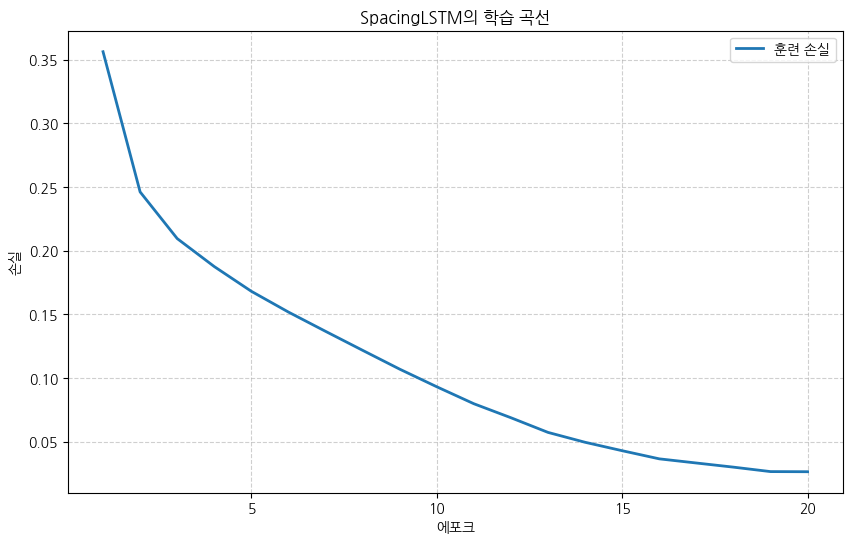

In [22]:
# 참고 - SpacingLSTM 학습(재현성을 위해 시드 재설정 후 같은 설정으로 학습)
common.set_seed()

# 모델 객체 생성
model_lstm = SpacingLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=LR)

# 학습 로거 설정
log_lstm = common.EpochLogger(EPOCHS, columns=('훈련 손실',), formats=('{:.4f}',))

# 학습 루프
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model_lstm, spacing_dataloader, criterion, optimizer, device)
    log_lstm.row(epoch, loss)
log_lstm.plot(title='SpacingLSTM의 학습 곡선')


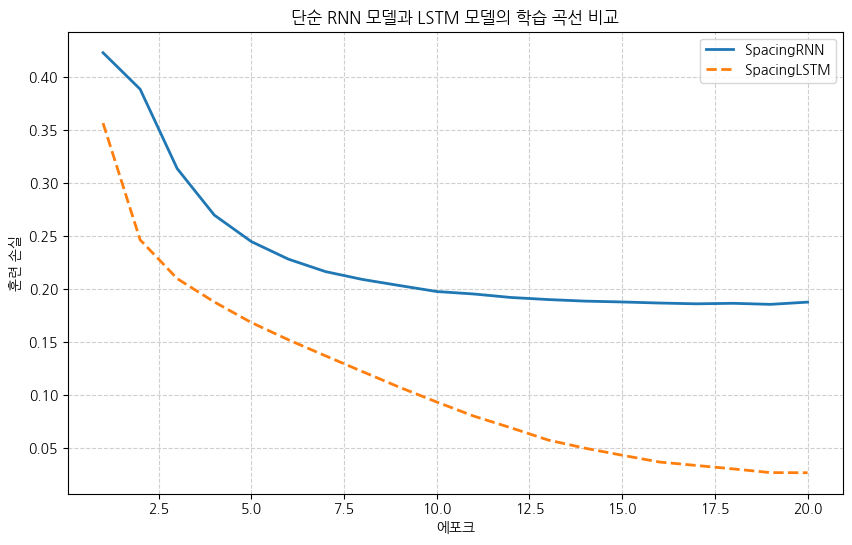

In [23]:
# 참고 - 두 모델의 학습 곡선 비교([그림 6-13])
viz.plot_histories(
    {
        'SpacingRNN': log.history['훈련 손실'],
        'SpacingLSTM': log_lstm.history['훈련 손실'],
    },
    title='단순 RNN 모델과 LSTM 모델의 학습 곡선 비교',
    y_label='훈련 손실',
)

In [24]:
# 참고 - SpacingLSTM 예측 결과
for i, test_input in enumerate(test_inputs):
    safe_input = filter_unknown_chars(test_input, vocab)
    print(f'\n-- {i + 1}번째 테스트 입력 --')
    head, tail = make_spacing(
        model_lstm, safe_input, vocab, SEQUENCE_LENGTH, device,
    )
    print(result_formatting(head, tail, safe_input))


-- 1번째 테스트 입력 --
-------------------------------------------------------------------------------
                                                                               
the most powerful of all the witches, and rules over the quadlings. besides, he
                                                                             
r castle stands on the edge of the desert, so she may know a way to cross it.
-------------------------------------------------------------------------------
* TP=30, TN=95, FP(X)=0, FN(V)=0 (정확도: 125/125 = 100.0%)

-- 2번째 테스트 입력 --
-------------------------------------------------------------------------------
        X                                                                      
told the m to go at once and get all her people. that would make dorothy happy.
V                 X    X                   X 
so i will say good -bye , said the princess .
-------------------------------------------------------------------------------
* TP=22, TN=70, FP(

## 정리

- 띄어쓰기 문제는 윈도우 마지막 글자 다음에 띄어쓰기가 있는지(0/1)를 예측하는 이진 분류 문제로 변환할 수 있다.
- 순환 신경망의 기울기 폭주를 막기 위해 학습 루프에 기울기 클리핑(`clip_grad_norm_`)을 적용한다.
- LSTM은 단순 RNN과 외부 인터페이스가 같아 `nn.RNN` 을 `nn.LSTM` 으로 바꾸기만 하면 되며, 장기 의존성을 더 잘 활용해 긴 문맥이 필요한 띄어쓰기 문제에서 성능이 더 좋다. 더 가벼운 변형인 `nn.GRU` 도 같은 방식으로 교체해 쓸 수 있다.

## 참고 - [그림 6-12] 과적합을 보여주는 학습 곡선

본문은 [코드 6-17] 이후 코드를 싣지 않고 학습 곡선([그림 6-12])만 보여준다. 여기서는 데이터의 20%를 검증 데이터로 분리해 `SpacingLSTM` 을 학습하면서 에포크마다 훈련 손실, 검증 손실, 검증 F1 점수를 함께 기록한다.

순차 데이터는 슬라이딩 윈도우가 만든 인접 샘플이 부분 문자열을 공유하므로, `random_split()` 으로 윈도우 샘플을 무작위 분리하면 훈련·검증 데이터에 정보가 중복돼 일반화 성능을 제대로 평가할 수 없다. 그래서 **윈도우를 적용하기 전 원본 순차 데이터를 8:2로 먼저 나눈 뒤** 각 덩어리에서 데이터셋을 만들고, 검증 데이터에 훈련 때 보지 못한 토큰이 나타나는 예외를 피하려고 통합 어휘 사전(`vocab`)을 공유한다.

띄어쓰기(양성, 1)는 전체 위치의 일부에 불과한 불균형 분류이므로 정확도 대신 **F1 점수**로 검증한다. 훈련 손실은 계속 줄지만 검증 F1 점수는 정점을 지나 오히려 떨어지는데, 이는 과적합이 진행 중이라는 신호다.

에포크    훈련 손실    검증 손실  검증 F1 점수     시간
  1/20       0.3784       0.3152        0.6603     0:14
  2/20       0.2597       0.2901        0.7185     0:30
  3/20       0.2192       0.2699        0.7111     0:45
  4/20       0.1951       0.2571        0.7274     1:00
  5/20       0.1760       0.2565        0.7415     1:15
  6/20       0.1602       0.2519        0.7635     1:31
  7/20       0.1445       0.2582        0.7617     1:47
  8/20       0.1292       0.2752        0.7600     2:02
  9/20       0.1143       0.2878        0.7517     2:15
 10/20       0.0994       0.3243        0.7564     2:28
최적(6 에포크/검증 F1 0.7635) 파라미터로 모델 복원
검증 F1 점수가 가장 높은 에포크: 6 (F1=0.7635)


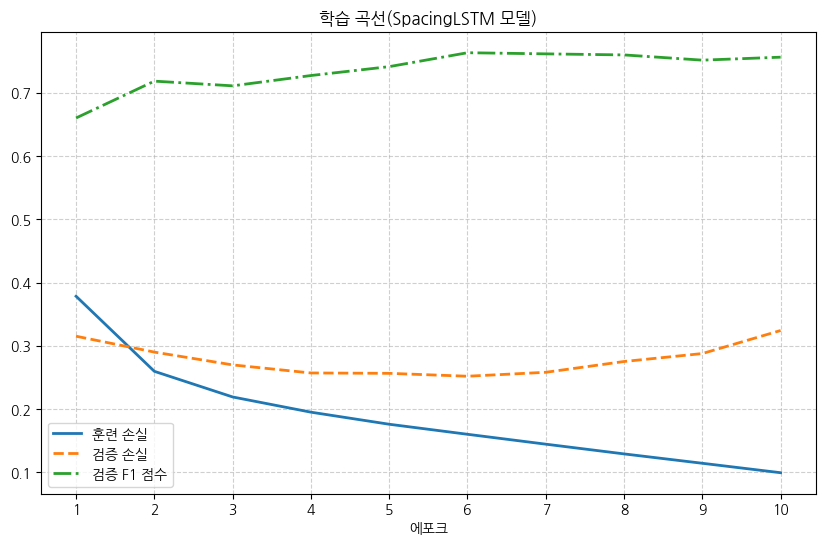

In [26]:
# 참고 - 과적합을 보여주는 학습 곡선([그림 6-12])
# 모델을 재학습한 후, 훈련 손실, 검증 손실과 함께 검증 F1 점수 그래프도 표시함

# 검증 손실과 F1 점수를 함께 반환하는 검증 함수
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    tp = fp = fn = 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss_sum += criterion(outputs, labels).item() * inputs.size(0)
        sample_size += inputs.size(0)
        preds = outputs.argmax(dim=1)
        # 띄어쓰기(양성=1)에 대한 TP/FP/FN 집계
        tp += int(((preds == 1) & (labels == 1)).sum())
        fp += int(((preds == 1) & (labels == 0)).sum())
        fn += int(((preds == 0) & (labels == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return loss_sum / sample_size, f1

# 재현성을 위해 시드 재설정
common.set_seed()

# 원본 순차 데이터를 8:2로 분리
split_idx = int(len(input_sequence) * 0.8)
train_input, valid_input = input_sequence[:split_idx], input_sequence[split_idx:]
train_target, valid_target = target_sequence[:split_idx], target_sequence[split_idx:]

# 훈련과 검증 데이터셋의 통합 어휘 사전(vocab) 사용: 미등장 토큰으로 인한 예외 방지
#   이미 전체 소설의 어휘 사전(vocab)이 있으므로 이를 재활용
train_dataset = SpacingDataset(train_input, train_target, vocab, SEQUENCE_LENGTH)
valid_dataset = SpacingDataset(valid_input, valid_target, vocab, SEQUENCE_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# SpacingLSTM 모델 객체 생성
model_es = SpacingLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
# 손실 함수, 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_es.parameters(), lr=LR)

# 에포크마다 검증 지표를 기록하고, 조기 종료 방식으로 학습(F1 점수를 기준으로 판단)
PATIENCE = 5                            # 참을성 한계
# 학습 로거 생성
log = common.EpochLogger(
    EPOCHS,
    columns=('훈련 손실', '검증 손실', '검증 F1 점수'),
    formats=('{:.4f}', '{:.4f}', '{:.4f}'),
    minimize='검증 F1 점수',           
    target_rows=EPOCHS
)

# 조기 종료 판단을 위한 변수
best_f1 = -float('inf')                 # 최댓값의 모델을 찾기 위해 충분히 작은 값으로 초기화
best_model_params = None                
patience_counter = 0
best_epoch = 0
#best_f1, best_epoch, best_state, wait, stopped = -1.0, 0, None, 0, None

# 학습 루프
for epoch in range(1, EPOCHS + 1):
    # 학습(에포크)
    train_loss = train_epoch(model_es, train_loader, criterion, optimizer, device)
    # 검증(에포크)
    valid_loss, valid_f1 = evaluate(model_es, valid_loader, criterion, device)
    # 학습 로그 기록
    log.row(epoch, train_loss, valid_loss, valid_f1)
    # 조기 종료 판단
    if valid_f1 > best_f1:              # F1은 클수록 좋으므로 최댓값을 추적
        # 현재 F1 점수가 최대일 때
        best_f1 = valid_f1
        # copy.deepcopy() 대신 다음과 같이 가중치를 복사해도 참조가 아닌 파라미터 딕셔너리 백업이 가능
        best_model_params = {k: v.detach().cpu().clone() for k, v in model_es.state_dict().items()}
        best_epoch = epoch
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            stopped = f'조기 종료: 검증 F1 점수가 {PATIENCE} 에포크 동안 개선되지 않음'
            break

print(f'최적({best_epoch} 에포크/검증 F1 {best_f1:.4f}) 파라미터로 모델 복원')
# 검증 손실을 충분히 큰 수(float('inf')) 또는 검증 F1 점수를 충분히 작은 수(-float('inf'))로 초기화하면
#   첫 번째 에포크에서 best_model_params가 백업이 되므로 best_model_params가 None인 상황은 발생하지 않는다.
#   다만, 혹시 모를 상황을 대비해 다음과 같이 None 체크를 수행하기도 한다.
if best_model_params is not None:
    model_es.load_state_dict(best_model_params)   # 검증 F1이 가장 높았던 가중치로 복원
print(f'검증 F1 점수가 가장 높은 에포크: {best_epoch} (F1={best_f1:.4f})')

# 학습 곡선 시각화([그림 6-12])
viz.plot_histories(
    {
        '훈련 손실': log.history['훈련 손실'],
        '검증 손실': log.history['검증 손실'],
        '검증 F1 점수': log.history['검증 F1 점수'],
    },
    title='학습 곡선(SpacingLSTM 모델)',
    y_label=None,
    x_ticks=log.epochs_seen,
)


In [20]:
for i, test_input in enumerate(test_inputs):
    safe_input = filter_unknown_chars(test_input, vocab)
    print(f'\n-- {i + 1}번째 테스트 입력 --')
    head, tail = make_spacing(
        model_es, safe_input, vocab, SEQUENCE_LENGTH, device,
    )
    print(result_formatting(head, tail, safe_input))


-- 1번째 테스트 입력 --
-------------------------------------------------------------------------------
                      X                                           X          X 
the most powerful of a ll the witches, and rules over the quadling s. besides ,
                 X             V                               V              X
 her castle stand s on the edgeof the desert, so she may know away to cross it 
 
.
-------------------------------------------------------------------------------
* TP=28, TN=90, FP(X)=5, FN(V)=2 (정확도: 118/125 = 94.4%)

-- 2번째 테스트 입력 --
-------------------------------------------------------------------------------
               V                             X                               X 
told them to goat once and get all her people . that would make dorothy happy .
                   X          V          X X 
 so i will say good -bye, saidthe princes s .
-------------------------------------------------------------------------------
* TP=21, TN=